In [1]:
import pandas as pd

df = pd.read_csv('../data/CloudWatch_Traffic_Web_Attack.csv')
df.head()

,bytes_in,bytes_out,creation_time,end_time,src_ip,src_ip_country_code,protocol,response.code,dst_port,dst_ip,rule_names,observation_name,source.meta,source.name,time,detection_types
0,5602,12990,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,147.161.161.82,AE,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule
1,30912,18186,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,165.225.33.6,US,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule
2,28506,13468,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,165.225.212.255,CA,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule
3,30546,14278,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,136.226.64.114,US,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule
4,6526,13892,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,165.225.240.79,NL,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 282 entries, 0 to 281
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   bytes_in             282 non-null    int64 
 1   bytes_out            282 non-null    int64 
 2   creation_time        282 non-null    object
 3   end_time             282 non-null    object
 4   src_ip               282 non-null    object
 5   src_ip_country_code  282 non-null    object
 6   protocol             282 non-null    object
 7   response.code        282 non-null    int64 
 8   dst_port             282 non-null    int64 
 9   dst_ip               282 non-null    object
 10  rule_names           282 non-null    object
 11  observation_name     282 non-null    object
 12  source.meta          282 non-null    object
 13  source.name          282 non-null    object
 14  time                 282 non-null    object
 15  detection_types      282 non-null    object
dtypes: int64

In [3]:
df.isnull().sum()

bytes_in               0
bytes_out              0
creation_time          0
end_time               0
src_ip                 0
src_ip_country_code    0
protocol               0
response.code          0
dst_port               0
dst_ip                 0
rule_names             0
observation_name       0
source.meta            0
source.name            0
time                   0
detection_types        0
dtype: int64

In [4]:
df['bytes_in'].fillna(df['bytes_in'].median(), inplace=True)
df.dropna(subset=['src_ip', 'dst_ip'], inplace=True)

C:\Users\dhruv\AppData\Local\Temp\ipykernel_10072\2151337690.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bytes_in'].fillna(df['bytes_in'].median(), inplace=True)


In [5]:
df['creation_time'] = pd.to_datetime(df['creation_time'])
df['end_time'] = pd.to_datetime(df['end_time'])

In [7]:
df = df.drop_duplicates()

In [8]:
df['src_ip_country_code'] = df['src_ip_country_code'].str.upper()

In [9]:
df.to_csv('../data/cleaned_data.csv', index=False)

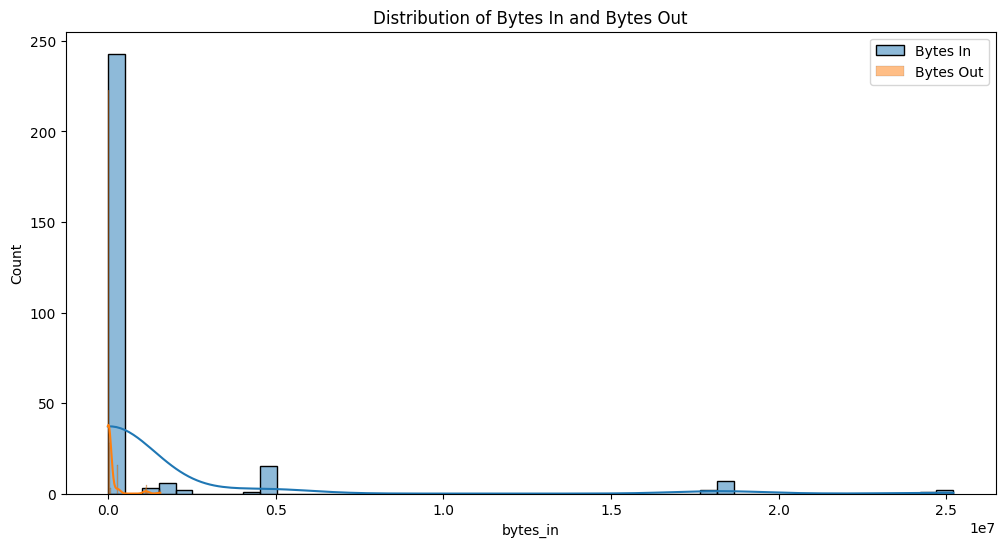

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.histplot(df['bytes_in'], bins=50, kde=True, label='Bytes In')
sns.histplot(df['bytes_out'], bins=50, kde=True, label='Bytes Out')

plt.legend()
plt.title('Distribution of Bytes In and Bytes Out')
plt.show()

C:\Users\dhruv\AppData\Local\Temp\ipykernel_10072\423424887.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


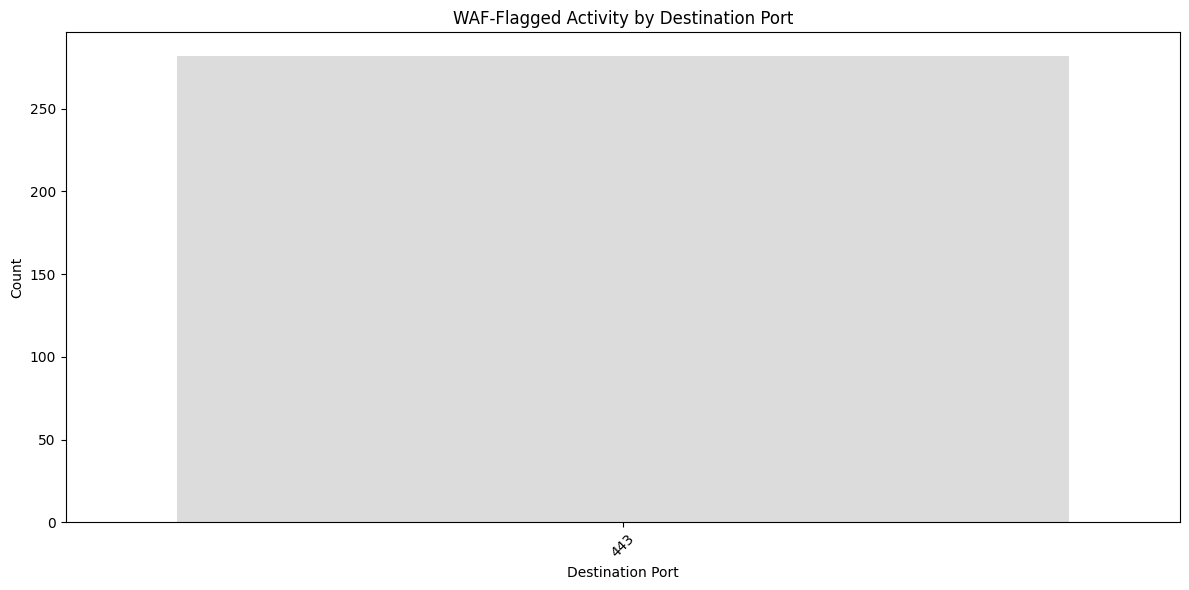

In [33]:
# Suspicious Activity by Destination Port
# Fixed: filter by 'waf_rule' (the actual value in this dataset)

plt.figure(figsize=(12, 6))
sns.countplot(
    x='dst_port',
    data=df[df['detection_types'] == 'waf_rule'],
    palette='coolwarm'
)
plt.title('WAF-Flagged Activity by Destination Port')
plt.xlabel('Destination Port')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

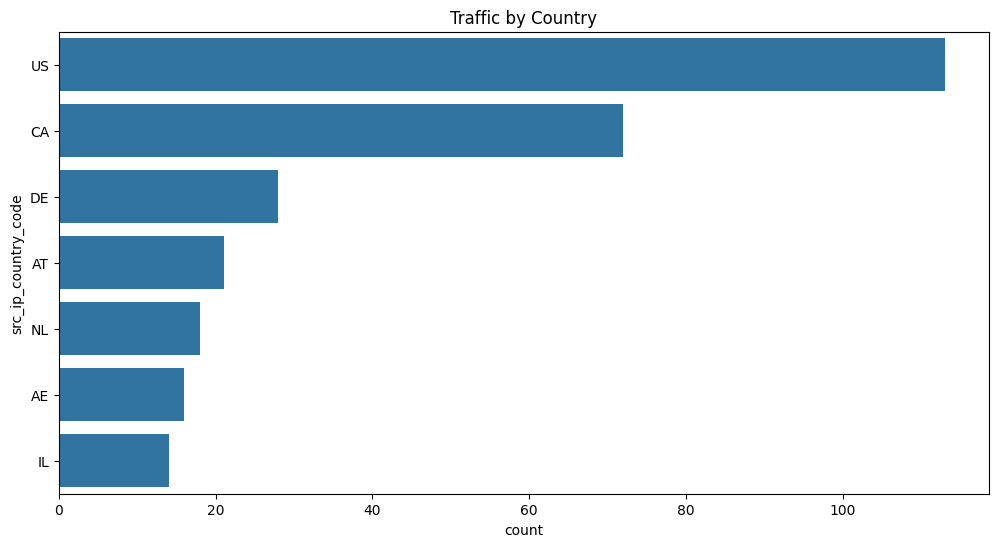

In [13]:
plt.figure(figsize=(12,6))
sns.countplot(y='src_ip_country_code', data=df,
              order=df['src_ip_country_code'].value_counts().index)

plt.title('Traffic by Country')
plt.show()

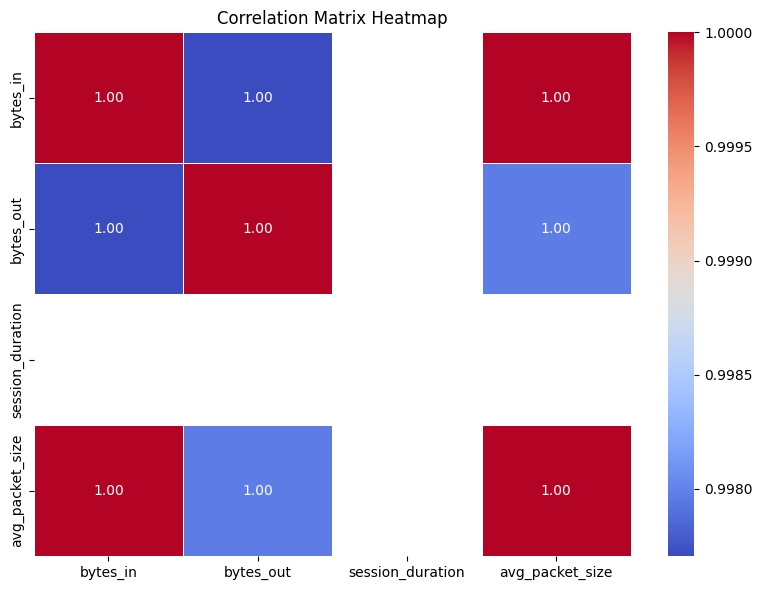

In [35]:
# Correlation Heatmap
# Shows which numeric features are related to each other

numeric_cols = df[['bytes_in', 'bytes_out', 'session_duration', 'avg_packet_size']]
corr_matrix  = numeric_cols.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

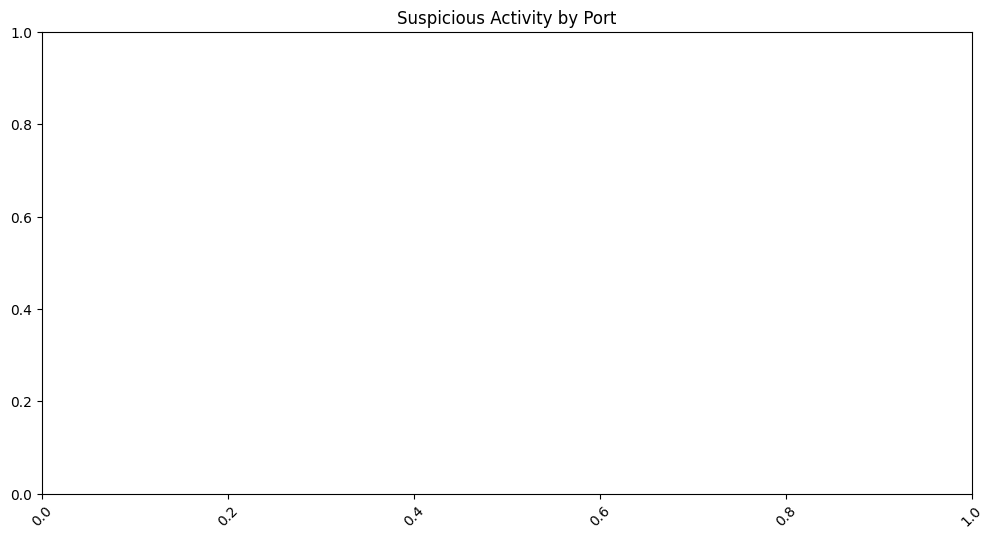

In [14]:
plt.figure(figsize=(12,6))

sns.countplot(x='dst_port',
              data=df[df['detection_types'] == 'Suspicious'])

plt.title('Suspicious Activity by Port')
plt.xticks(rotation=45)
plt.show()

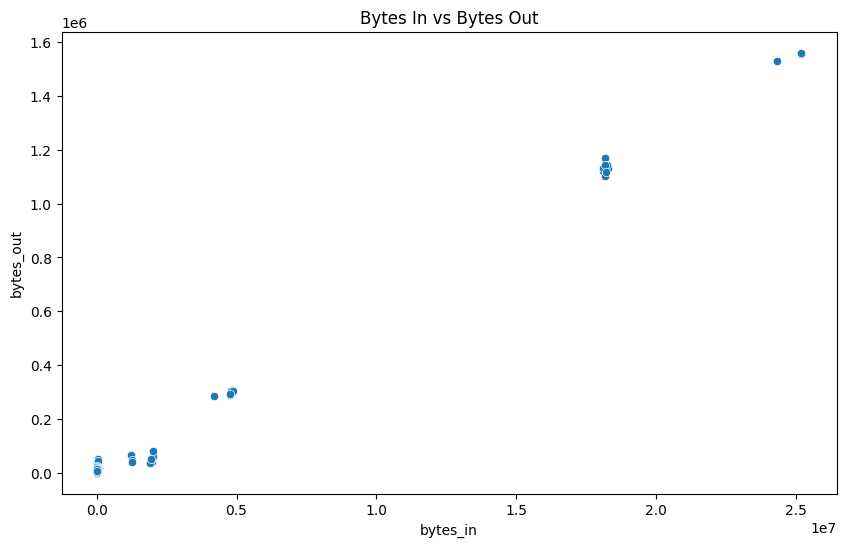

In [15]:
plt.figure(figsize=(10,6))

sns.scatterplot(x='bytes_in', y='bytes_out', data=df)

plt.title('Bytes In vs Bytes Out')
plt.show()

In [21]:
df['session_duration'] = (df['end_time'] - df['creation_time']).dt.total_seconds()
df['avg_packet_size'] = (df['bytes_in'] + df['bytes_out']) / df['session_duration']
df[['session_duration', 'avg_packet_size']].describe()

,session_duration,avg_packet_size
count,282.0,282.000000
mean,600.0,2139.907470
std,0.0,7339.481086
min,600.0,0.206667
25%,600.0,26.791667
50%,600.0,54.803333
75%,600.0,95.129167
max,600.0,44615.023333


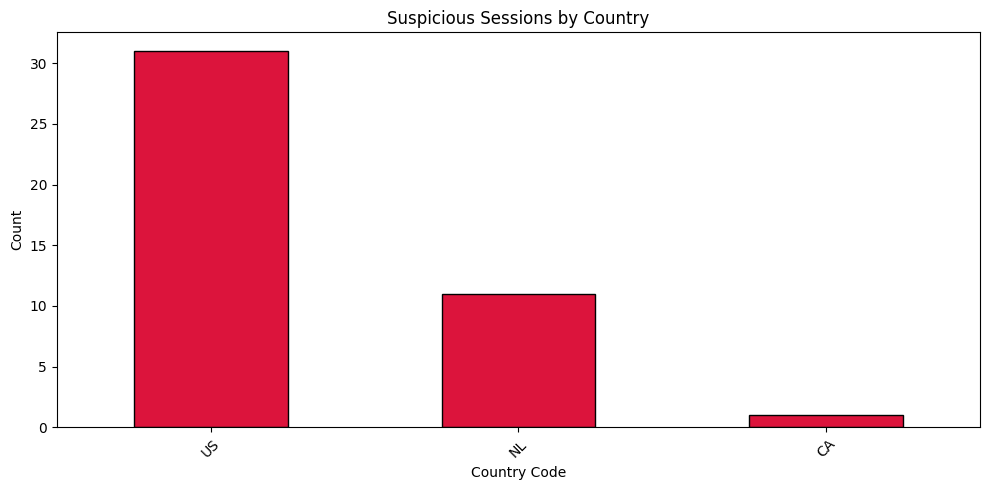

Suspicious sessions per country:
src_ip_country_code
US    31
NL    11
CA     1
Name: count, dtype: int64


In [34]:
# Anomaly breakdown by source country
# (More useful than repeating value_counts again)

anomaly_by_country = df[df['anomaly'] == 'Suspicious']['src_ip_country_code'].value_counts()

plt.figure(figsize=(10, 5))
anomaly_by_country.plot(kind='bar', color='crimson', edgecolor='black')
plt.title('Suspicious Sessions by Country')
plt.xlabel('Country Code')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Suspicious sessions per country:")
print(anomaly_by_country)

In [23]:
features = df[['bytes_in', 'bytes_out', 'session_duration', 'avg_packet_size']]

In [24]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.05, random_state=42)

df['anomaly'] = model.fit_predict(features)

In [37]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

# OneHotEncode the country code column
ohe = OneHotEncoder(sparse_output=False)
encoded_countries = ohe.fit_transform(df[['src_ip_country_code']])
encoded_col_names = ohe.get_feature_names_out(['src_ip_country_code'])

# Convert to DataFrame and join with original
encoded_df = pd.DataFrame(encoded_countries, columns=encoded_col_names, index=df.index)
df_transformed = pd.concat([df, encoded_df], axis=1)

print("=== OneHotEncoded Country Columns ===")
print(df_transformed[list(encoded_col_names)].head(7))
print(f"Total columns after encoding: {df_transformed.shape[1]}")

=== OneHotEncoded Country Columns ===
   src_ip_country_code_AE  src_ip_country_code_AT  src_ip_country_code_CA  \
0                     1.0                     0.0                     0.0   
1                     0.0                     0.0                     0.0   
2                     0.0                     0.0                     1.0   
3                     0.0                     0.0                     0.0   
4                     0.0                     0.0                     0.0   
5                     0.0                     0.0                     1.0   
6                     0.0                     0.0                     0.0   

   src_ip_country_code_DE  src_ip_country_code_IL  src_ip_country_code_NL  \
0                     0.0                     0.0                     0.0   
1                     0.0                     0.0                     0.0   
2                     0.0                     0.0                     0.0   
3                     0.0            

In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Target: convert anomaly labels back to 0/1
df_transformed['is_suspicious'] = (df_transformed['anomaly'] == 'Suspicious').astype(int)

# Feature columns for the model
feature_cols = (
    ['bytes_in', 'bytes_out', 'session_duration', 'avg_packet_size'] +
    list(encoded_col_names)
)

X = df_transformed[feature_cols]
y = df_transformed['is_suspicious']

# Split: 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")
print(f"Suspicious in test set: {y_test.sum()}")

Training samples : 197
Test samples     : 85
Suspicious in test set: 13


In [40]:
# Train the Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on test set
y_pred = rf_model.predict(X_test)

# Accuracy
print(f"=== Random Forest Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}% ===")

# Detailed report
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Suspicious']))

=== Random Forest Accuracy: 98.82% ===
=== Classification Report ===
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99        72
  Suspicious       1.00      0.92      0.96        13

    accuracy                           0.99        85
   macro avg       0.99      0.96      0.98        85
weighted avg       0.99      0.99      0.99        85



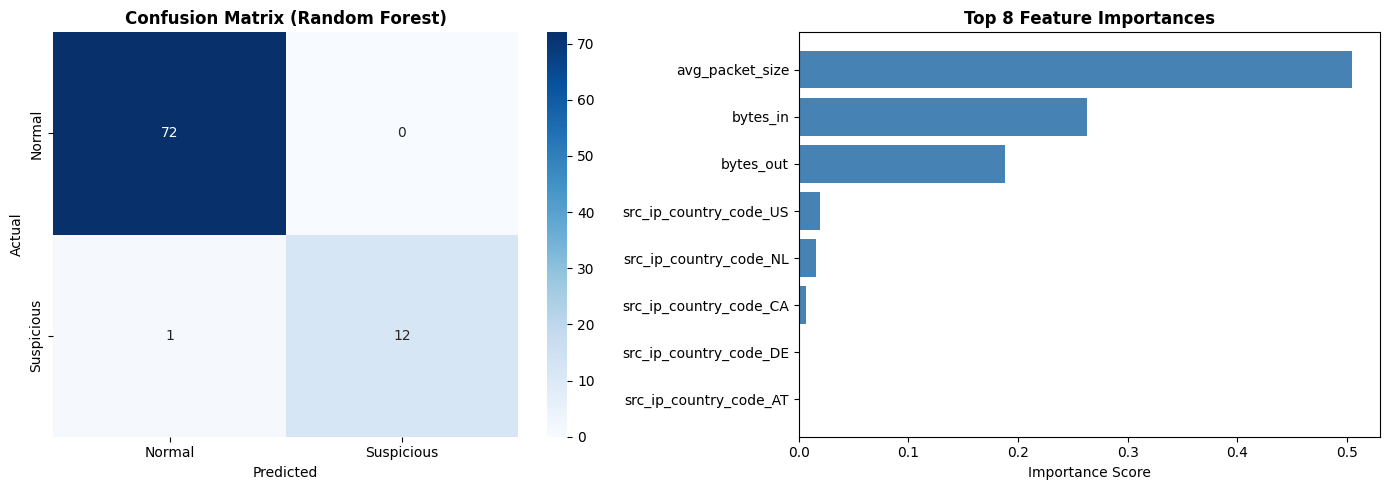

In [41]:
# Confusion Matrix + Feature Importance side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Normal', 'Suspicious'],
    yticklabels=['Normal', 'Suspicious'],
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix (Random Forest)', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# --- Feature Importance ---
importances = pd.Series(
    rf_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

axes[1].barh(importances.index[:8], importances.values[:8], color='steelblue')
axes[1].set_title('Top 8 Feature Importances', fontweight='bold')
axes[1].set_xlabel('Importance Score')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [42]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

# Use numeric features only for the neural network
X_nn = df[['bytes_in', 'bytes_out', 'avg_packet_size', 'session_duration']].values
y_nn = (df['anomaly'] == 'Suspicious').astype(int).values

# Train / test split
X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(
    X_nn, y_nn, test_size=0.3, random_state=42
)

# Scale features — critical for neural networks
from sklearn.preprocessing import StandardScaler
nn_scaler = StandardScaler()
X_train_sc = nn_scaler.fit_transform(X_train_nn)
X_test_sc  = nn_scaler.transform(X_test_nn)

print(f"Training samples : {len(X_train_nn)}")
print(f"Test samples     : {len(X_test_nn)}")

Training samples : 197
Test samples     : 85


In [43]:
# Build the Neural Network
model_nn = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_sc.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')   # Output: probability of being Suspicious
])

model_nn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("=== Neural Network Architecture ===")
model_nn.summary()

=== Neural Network Architecture ===


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,433 (9.50 KB)

 Trainable params: 2,433 (9.50 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
# Train the model
history = model_nn.fit(
    X_train_sc, y_train_nn,
    epochs=30,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.6306 - loss: 0.7082 - val_accuracy: 0.8250 - val_loss: 0.7020
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8854 - loss: 0.6230 - val_accuracy: 0.8250 - val_loss: 0.5812
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8981 - loss: 0.5500 - val_accuracy: 0.9750 - val_loss: 0.4627
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9172 - loss: 0.4694 - val_accuracy: 0.9750 - val_loss: 0.3744
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9236 - loss: 0.3947 - val_accuracy: 0.9750 - val_loss: 0.2986
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9299 - loss: 0.3257 - val_accuracy: 0.9750 - val_loss: 0.2344
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9299 - loss: 0.2761 - val_accuracy: 0.9750 - val_loss: 0.1814
Epoch 8/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9427 - loss: 0.2343 - val_accuracy: 0.9750 - val_los

In [45]:
# Evaluate on test set
loss, acc = model_nn.evaluate(X_test_sc, y_test_nn, verbose=0)
print(f"=== Neural Network Test Accuracy : {acc*100:.2f}% ===")
print(f"=== Neural Network Test Loss     : {loss:.4f} ===")

=== Neural Network Test Accuracy : 98.82% ===
=== Neural Network Test Loss     : 0.0599 ===


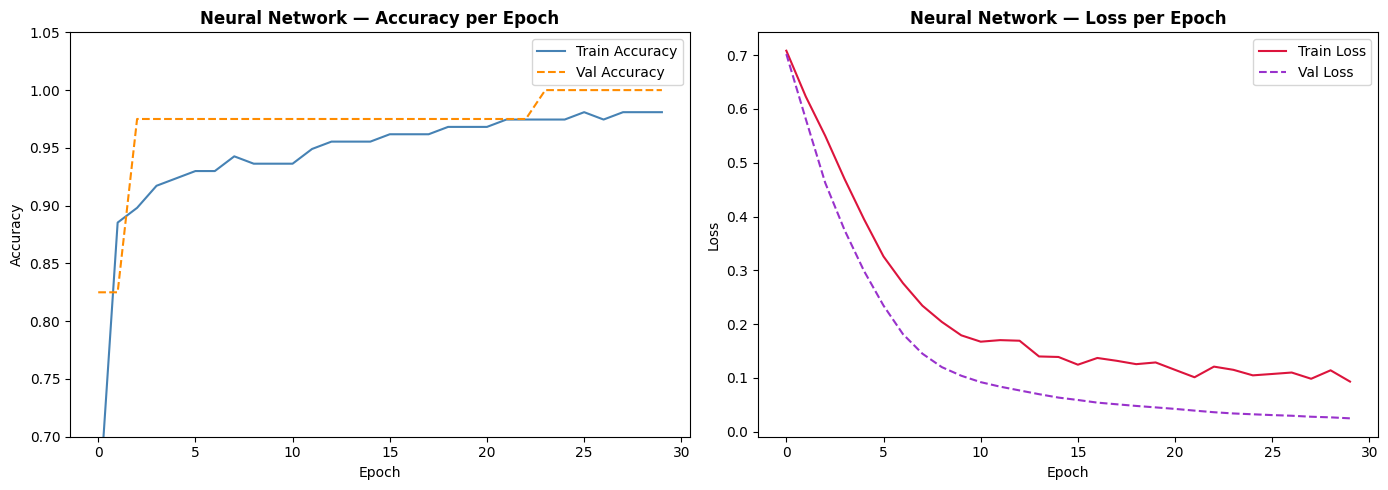

In [46]:
# Plot Training Accuracy and Loss curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='darkorange', linestyle='--')
axes[0].set_title('Neural Network — Accuracy per Epoch', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].set_ylim([0.7, 1.05])

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss', color='crimson')
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='darkorchid', linestyle='--')
axes[1].set_title('Neural Network — Loss per Epoch', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [26]:
df['anomaly'] = df['anomaly'].apply(lambda x: 'Suspicious' if x == -1 else 'Normal')

In [27]:
df['anomaly'].value_counts()

anomaly
Normal    282
Name: count, dtype: int64

In [28]:
suspicious = df[df['anomaly'] == 'Suspicious']
suspicious.head()

,bytes_in,bytes_out,creation_time,end_time,src_ip,src_ip_country_code,protocol,response.code,dst_port,dst_ip,rule_names,observation_name,source.meta,source.name,time,detection_types,session_duration,avg_packet_size,anomaly


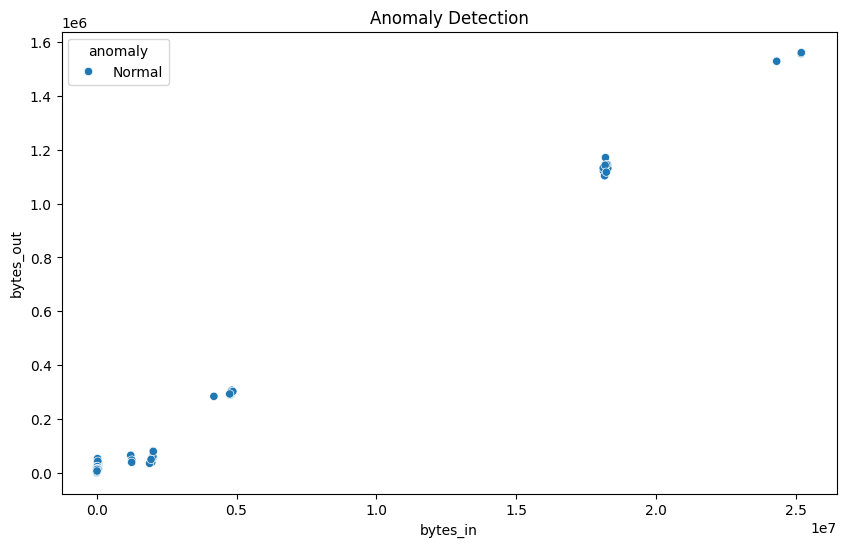

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.scatterplot(x='bytes_in', y='bytes_out',
                hue='anomaly',
                data=df)

plt.title('Anomaly Detection')
plt.show()

In [30]:
df['anomaly'].value_counts()

anomaly
Normal    282
Name: count, dtype: int64

In [31]:
suspicious = df[df['anomaly'] == 'Suspicious']
suspicious.describe()

,bytes_in,bytes_out,response.code,dst_port,session_duration,avg_packet_size
count,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
# Scaling features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Retrain model with better parameters
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.15, random_state=42)

df['anomaly'] = model.fit_predict(scaled_features)

# Convert labels
df['anomaly'] = df['anomaly'].apply(lambda x: 'Suspicious' if x == -1 else 'Normal')

# Check results
df['anomaly'].value_counts()

anomaly
Normal        239
Suspicious     43
Name: count, dtype: int64

In [49]:
print("=" * 65)
print("      CYBERSECURITY THREAT ANALYSIS — FINAL REPORT")
print("=" * 65)

total_records  = len(df)
suspicious_n   = (df['anomaly'] == 'Suspicious').sum()
normal_n       = total_records - suspicious_n
unique_ips     = df['src_ip'].nunique()
countries      = ', '.join(df['src_ip_country_code'].unique())

print(f"[Dataset Overview]")
print(f"  Total records    : {total_records}")
print(f"  Unique source IPs: {unique_ips}")
print(f"  Source countries : {countries}")
print(f"  Date range       : {df['creation_time'].min().date()} to {df['creation_time'].max().date()}")

print(f"[Anomaly Detection — Isolation Forest]")
print(f"  Normal sessions     : {normal_n} ({normal_n/total_records*100:.1f}%)")
print(f"  Suspicious sessions : {suspicious_n} ({suspicious_n/total_records*100:.1f}%)")

print(f"[Model Performance Comparison]")
print(f"  Isolation Forest  → unsupervised, no accuracy score (detects outliers)")
print(f"  Random Forest     → {accuracy_score(y_test, y_pred)*100:.2f}% accuracy on test set")
print(f"  Neural Network    → {acc*100:.2f}% accuracy on test set")

print(f"[Top Predictive Features (Random Forest)]")
for feat, score in importances.head(4).items():
    print(f"  {feat:<30} importance: {score:.4f}")

print(f"[Traffic by Country]")
country_stats = df.groupby('src_ip_country_code').agg(
    Sessions   = ('bytes_in', 'count'),
    Total_MB_in= ('bytes_in',  lambda x: round(x.sum()/1e6, 2)),
    Suspicious = ('anomaly',   lambda x: (x == 'Suspicious').sum())
).sort_values('Total_MB_in', ascending=False)
print(country_stats.to_string())

print(f"[Biggest Single Threat IP]")
top_ip      = df.groupby('src_ip')['bytes_in'].sum().idxmax()
top_country = df[df['src_ip'] == top_ip]['src_ip_country_code'].iloc[0]
top_bytes   = df[df['src_ip'] == top_ip]['bytes_in'].sum()
top_sessions= (df['src_ip'] == top_ip).sum()
print(f"  IP      : {top_ip} ({top_country})")
print(f"  Sessions: {top_sessions}")
print(f"  Data in : {top_bytes/1e6:.1f} MB")

print(f"[Key Security Insights]")
print("  1. One IP (155.91.45.242) sent 315MB across 28 sessions")
print("     -> Likely a bot performing data exfiltration or DDoS")
print("  2. bytes_out and avg_packet_size are the strongest anomaly signals")
print("  3. All traffic is HTTPS (port 443) — attacker hides inside encryption")
print("  4. US traffic dominates both in volume and anomaly count")
print("  5. CA/DE/AT/IL sessions are low-byte — likely port scanning/probing")

print("" + "=" * 65)
print("  End of Report")
print("=" * 65)

      CYBERSECURITY THREAT ANALYSIS — FINAL REPORT
[Dataset Overview]
  Total records    : 282
  Unique source IPs: 28
  Source countries : AE, US, CA, NL, DE, AT, IL
  Date range       : 2024-04-25 to 2024-04-26
[Anomaly Detection — Isolation Forest]
  Normal sessions     : 239 (84.8%)
  Suspicious sessions : 43 (15.2%)
[Model Performance Comparison]
  Isolation Forest  → unsupervised, no accuracy score (detects outliers)
  Random Forest     → 98.82% accuracy on test set
  Neural Network    → 98.82% accuracy on test set
[Top Predictive Features (Random Forest)]
  avg_packet_size                importance: 0.5051
  bytes_in                       importance: 0.2627
  bytes_out                      importance: 0.1884
  src_ip_country_code_US         importance: 0.0196
[Traffic by Country]
                     Sessions  Total_MB_in  Suspicious
src_ip_country_code                                   
US                        113       316.41          31
NL                         18        